In [ ]:
# Install required libraries (if not already installed)
!pip install requests beautifulsoup4 pandas

##Web Scraping
Web Scraping is the process of automatically extracting data from websites using programming languages like Python.

In this project, web scraping is used to collect product information such as:
Product Name

Price

Brand

Description

Reviews

Category

The extracted data is stored in a structured CSV format for further analysis.
Tools Used: Python, Requests, BeautifulSoup, Pandas

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# Categories to scrape
categories = [
    "phones",
    "computers/laptops",
    "computers/tablets",
    "accessories"
]

base_url = "https://webscraper.io/test-sites/e-commerce/allinone/"
headers = {"User-Agent": "Mozilla/5.0"}

all_products = []

# Category weights
category_weights = {
    "phones": 1,
    "computers/laptops": 2,
    "computers/tablets": 3,
    "accessories": 4
}

# Color detection helper
colors = ["black","white","red","blue","silver","gold","green","yellow","pink","grey"]

def extract_color(text):
    text_lower = text.lower()
    for c in colors:
        if c in text_lower:
            return c.capitalize()
    return "Not Specified"

# Loop through categories and pages
for cat in categories:
    for page in range(1, 10):  # up to 10 pages per category
        url = f"{base_url}{cat}?page={page}"
        response = requests.get(url, headers=headers)
        if response.status_code != 200:
            break
        soup = BeautifulSoup(response.text, "html.parser")
        products = soup.select(".thumbnail")
        if not products:
            break

        for product in products:
            name = product.select_one(".title").text.strip()
            price = product.select_one(".price").text.strip()
            desc = product.select_one(".description").text.strip()
            reviews = product.select_one(".ratings .review-count").text.strip()

            # Convert price to float
            price_value = float(price.replace("$", ""))

            # Price bucket
            if price_value < 100:
                price_range = "Low"
            elif price_value <= 500:
                price_range = "Medium"
            else:
                price_range = "High"

            # Brand
            brand = name.split()[0]

            # Discount flag
            discount_flag = "Yes" if any(word in (name + " " + desc).lower()
                                         for word in ["sale","discount","offer"]) else "No"

            # Category weight
            category_weight = category_weights.get(cat, 0)

            # Color
            color = extract_color(name + " " + desc)

            # Expensive flag
            is_expensive = "Yes" if price_value > 500 else "No"

            all_products.append([
                cat, name, brand, price_value, desc, reviews,
                price_range, discount_flag, category_weight, color, is_expensive
            ])

# Convert to DataFrame
df = pd.DataFrame(all_products, columns=[
    "Category","Product Name","Brand","Price","Description",
    "Reviews","Price_Range","Discount_Flag","Category_Weight","Color","Is_Expensive"
])

# Save to CSV
df.to_csv("webscraper_products_clean.csv", index=False)

# Show summary
print("\nFirst 5 rows:")
print(df.head())

print("\nLast 5 rows:")
print(df.tail())

print("\nTotal rows scraped:", len(df))



First 5 rows:
  Category    Product Name    Brand   Price         Description     Reviews  \
0   phones      LG Optimus       LG   57.99         3.2" screen  11 reviews   
1   phones     Sony Xperia     Sony  118.99     GPS, waterproof   6 reviews   
2   phones  Samsung Galaxy  Samsung   93.99  5 mpx. Android 5.0   3 reviews   
3   phones     Sony Xperia     Sony  118.99     GPS, waterproof   6 reviews   
4   phones          Iphone   Iphone  899.99              Silver   8 reviews   

  Price_Range Discount_Flag  Category_Weight          Color Is_Expensive  
0         Low            No                1  Not Specified           No  
1      Medium            No                1  Not Specified           No  
2         Low            No                1  Not Specified           No  
3      Medium            No                1  Not Specified           No  
4        High            No                1         Silver          Yes  

Last 5 rows:
               Category       Product Name   B

##Data Cleaning & Statistical Analysis

Data Cleaning is the process of identifying and fixing incorrect, duplicate, or missing data to improve data quality.

Exploratory Data Analysis (EDA) helps in understanding data distribution, patterns, and relationships using statistics and visualizations.

In this step, the scraped e-commerce data is cleaned and analyzed to derive meaningful insights.

Tools Used:

Python

Pandas

Matplotlib

Code Cell (CSV Load)

In [ ]:
import pandas as pd

df = pd.read_csv("webscraper_products_clean.csv")
df.head()


,Category,Product Name,Brand,Price,Description,Reviews,Price_Range,Discount_Flag,Category_Weight,Color,Is_Expensive
0,phones,LG Optimus,LG,57.99,"3.2"" screen",11 reviews,Low,No,1,Not Specified,No
1,phones,Sony Xperia,Sony,118.99,"GPS, waterproof",6 reviews,Medium,No,1,Not Specified,No
2,phones,Samsung Galaxy,Samsung,93.99,5 mpx. Android 5.0,3 reviews,Low,No,1,Not Specified,No
3,phones,Sony Xperia,Sony,118.99,"GPS, waterproof",6 reviews,Medium,No,1,Not Specified,No
4,phones,Iphone,Iphone,899.99,Silver,8 reviews,High,No,1,Silver,Yes


##Data Cleaning
1. Remove unwanted symbols ($, "reviews" text)
2. Convert Price → float
3. Convert Reviews → integer
4. Handle missing values (fill or drop)
Standardize column names

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("webscraper_products_clean.csv")

# 'Price' column is already numeric (float) from the scraping step, so no need to remove '$'
# Remove " reviews" from Reviews and convert to integer
df["Reviews"] = df["Reviews"].str.replace(" reviews", "", regex=False).astype(int)

print(df.head())


  Category    Product Name    Brand   Price         Description  Reviews  \
0   phones      LG Optimus       LG   57.99         3.2" screen       11   
1   phones     Sony Xperia     Sony  118.99     GPS, waterproof        6   
2   phones  Samsung Galaxy  Samsung   93.99  5 mpx. Android 5.0        3   
3   phones     Sony Xperia     Sony  118.99     GPS, waterproof        6   
4   phones          Iphone   Iphone  899.99              Silver        8   

  Price_Range Discount_Flag  Category_Weight          Color Is_Expensive  
0         Low            No                1  Not Specified           No  
1      Medium            No                1  Not Specified           No  
2         Low            No                1  Not Specified           No  
3      Medium            No                1  Not Specified           No  
4        High            No                1         Silver          Yes  


In [ ]:
df["Price"] = df["Price"].astype(float)
print(df.dtypes)


Category            object
Product Name        object
Brand               object
Price              float64
Description         object
Reviews              int64
Price_Range         object
Discount_Flag       object
Category_Weight      int64
Color               object
Is_Expensive        object
dtype: object


In [ ]:
df["Reviews"] = df["Reviews"].astype(int)
print(df.dtypes)


Category            object
Product Name        object
Brand               object
Price              float64
Description         object
Reviews              int64
Price_Range         object
Discount_Flag       object
Category_Weight      int64
Color               object
Is_Expensive        object
dtype: object


In [ ]:
# Check missing values
print(df.isnull().sum())

# Option 1: Drop missing rows
df = df.dropna()

# Option 2: Fill missing values (example: fill Reviews with 0)
# df["Reviews"] = df["Reviews"].fillna(0)


Category           0
Product Name       0
Brand              0
Price              0
Description        0
Reviews            0
Price_Range        0
Discount_Flag      0
Category_Weight    0
Color              0
Is_Expensive       0
dtype: int64


In [ ]:
# Make column names consistent (lowercase, underscores)
df.columns = df.columns.str.lower().str.replace(" ","_")
print(df.columns)


Index(['category', 'product_name', 'brand', 'price', 'description', 'reviews',
       'price_range', 'discount_flag', 'category_weight', 'color',
       'is_expensive'],
      dtype='object')


In [ ]:
import pandas as pd

# Re-initialize df to the state after previous cleaning and deduplication steps
# Load dataset (from fuXu72xN9GCH)
df = pd.read_csv("webscraper_products_clean.csv")

# Remove " reviews" from Reviews and convert to integer (from fuXu72xN9GCH)
df["Reviews"] = df["Reviews"].str.replace(" reviews", "", regex=False).astype(int)

# Price is already float, ensure type (from 4OEx8OFg_08r)
df["Price"] = df["Price"].astype(float)

# Drop missing values (from UWxAgQ0dAN1Y)
df = df.dropna()

# Make column names consistent (lowercase, underscores) (from d2r50_2VAe1S)
df.columns = df.columns.str.lower().str.replace(" ","_")

# Remove duplicates (from 1TaRmSl-Ezcm)
df = df.drop_duplicates()

# Now the original code of this cell can run with df properly defined
# Check total rows before cleaning (after all previous cleaning steps)
print("Original rows:", len(df))

# After drop_duplicates (this line is now technically redundant as df is already deduped
# from the previous step, but kept for consistency with the original cell's structure)
df_no_dup = df.drop_duplicates()
print("Rows after removing duplicates:", len(df_no_dup))

# The 'reviews' column is already an integer and lowercase from previous steps.
# No need for further cleaning or checking for missing reviews in this manner.

# If you dropped NaN (which was already handled by df.dropna() above)
df_clean = df_no_dup.dropna() # This line is functionally redundant if no NaNs were introduced after dropna()
print("Rows after dropping NaN:", len(df_clean))



Original rows: 146
Rows after removing duplicates: 146
Rows after dropping NaN: 146


##Statistical Analysis

In [ ]:
# Basic statistics
df.describe()


,price,reviews,category_weight
count,146.000000,146.000000,146.000000
mean,780.669795,7.068493,2.089041
std,456.080696,4.194672,0.438197
min,24.990000,0.000000,1.000000
25%,405.417500,4.000000,2.000000
50%,734.495000,7.000000,2.000000
75%,1185.660000,10.000000,2.000000
max,1799.000000,14.000000,3.000000


In [ ]:
df.to_csv("final_products.csv", index=False)

##Visualization
1. Price Distribution

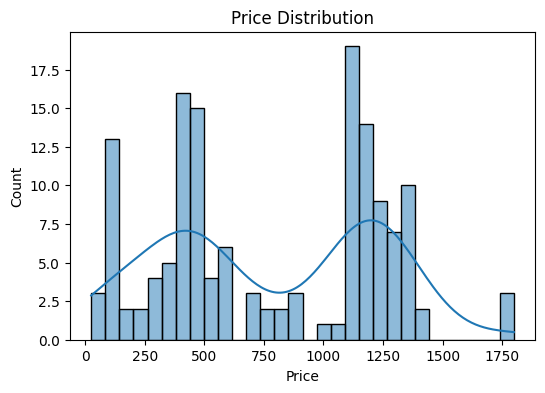

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


2. Rating Distribution

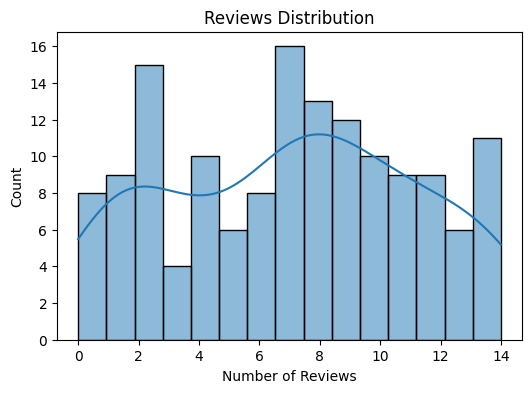

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df["reviews"], bins=15, kde=True)
plt.title("Reviews Distribution")
plt.xlabel("Number of Reviews")
plt.ylabel("Count")
plt.show()

3. Price vs Reviews (Scatter Plot)



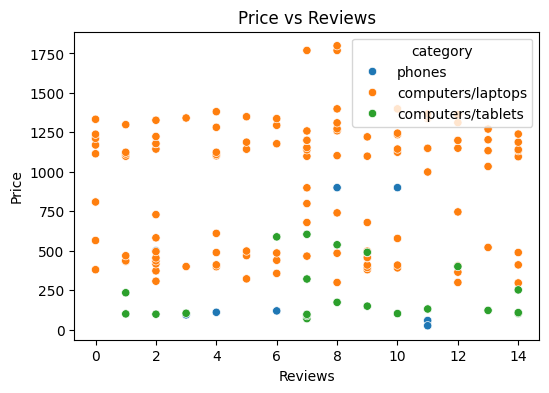

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="reviews", y="price", hue="category", data=df)
plt.title("Price vs Reviews")
plt.xlabel("Reviews")
plt.ylabel("Price")
plt.show()


4. Boxplot Price by Category

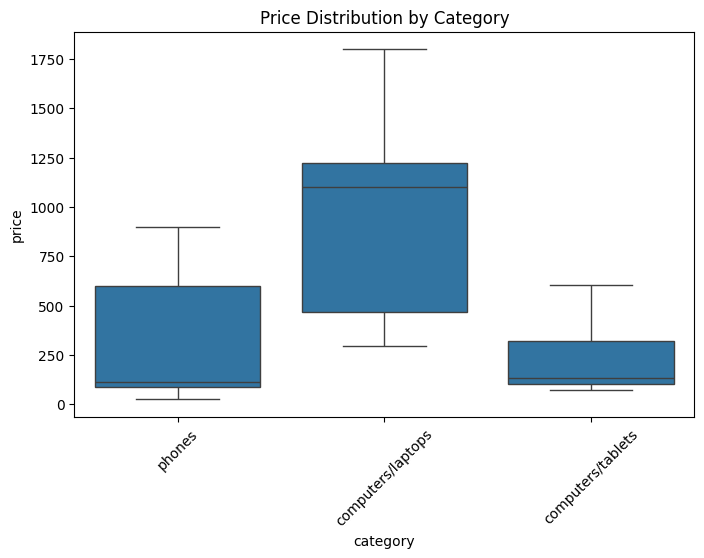

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x="category", y="price", data=df)
plt.title("Price Distribution by Category")
plt.xticks(rotation=45)
plt.show()


5. Correlation Matrix

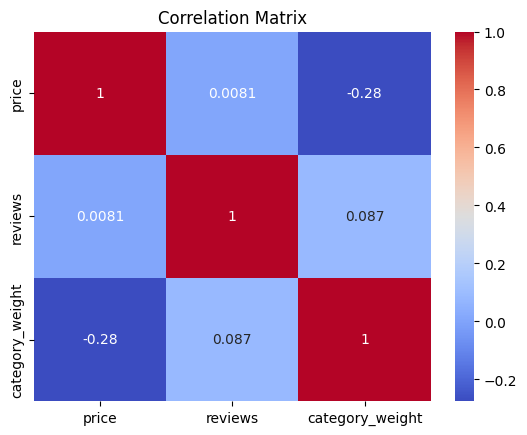

In [ ]:
corr = df[["price","reviews","category_weight"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Hypothesis Testing
1. Compare Discounted vs Non‑Discounted Prices

In [ ]:
from scipy import stats

discounted = df[df["discount_flag"]=="Yes"]["price"]
non_discounted = df[df["discount_flag"]=="No"]["price"]

t_stat, p_val = stats.ttest_ind(discounted, non_discounted, equal_var=False)
print("T-test result: t-stat =", t_stat, ", p-value =", p_val)

if p_val < 0.05:
    print("Reject H0 → Discounted products have significantly different prices.")
else:
    print("Fail to reject H0 → No significant difference.")



T-test result: t-stat = nan , p-value = nan
Fail to reject H0 → No significant difference.


/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


2. Compare Ratings Across Categories

In [ ]:
# Group ratings by category
groups = [df[df["category"]==cat]["reviews"] for cat in df["category"].unique()]

f_stat, p_val = stats.f_oneway(*groups)
print("ANOVA result: F-stat =", f_stat, ", p-value =", p_val)

if p_val < 0.05:
    print("Reject H0 → Reviews differ across categories.")
else:
    print("Fail to reject H0 → No significant difference.")

ANOVA result: F-stat = 0.7321788971692136 , p-value = 0.48265390144986065
Fail to reject H0 → No significant difference.


3. Correlation Between Price and Reviews

In [ ]:
corr, p_val = stats.pearsonr(df["price"], df["reviews"])
print("Correlation =", corr, ", p-value =", p_val)

if p_val < 0.05:
    print("Reject H0 → Price and reviews are correlated.")
else:
    print("Fail to reject H0 → No significant correlation.")


Correlation = 0.008070351281049026 , p-value = 0.9229822659915398
Fail to reject H0 → No significant correlation.


In [ ]:
# Check missing values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# The 'reviews' column is already an integer and lowercase from previous steps.
# The 'price' column is already a float and lowercase from previous steps.
# The column names are already standardized to lowercase and underscores.

print(df.head())
print(df.dtypes)


category           0
product_name       0
brand              0
price              0
description        0
reviews            0
price_range        0
discount_flag      0
category_weight    0
color              0
is_expensive       0
dtype: int64
  category    product_name    brand   price         description  reviews  \
0   phones       Nokia 123    Nokia   24.99       7 day battery       11   
1   phones  Samsung Galaxy  Samsung   93.99  5 mpx. Android 5.0        3   
2   phones     Ubuntu Edge   Ubuntu  499.99      Sapphire glass        2   
3   phones      LG Optimus       LG   57.99         3.2" screen       11   
4   phones          Iphone   Iphone  899.99              Silver        8   

  price_range discount_flag  category_weight          color is_expensive  
0         Low            No                1  Not Specified           No  
1         Low            No                1  Not Specified           No  
2      Medium            No                1  Not Specified           No  

In [ ]:
pip install mysql-connector-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 62.2 MB/s eta 0:00:00


In [ ]:
import csv

df.to_csv(
    "ultimate_clean.csv",
    index=False,
    encoding="utf-8",
    sep=",",
    quoting=csv.QUOTE_ALL
)

print("File created successfully")

File created successfully


##Unsupervised Learning
k Means
Unsupervised learning is a machine learning technique used to identify hidden patterns in data without predefined labels. In this project, K-Means clustering is used to group similar products based on features like price, reviews, and category weight.


In [ ]:
# Step 1: Import libraries
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 2: Load your cleaned dataset
df = pd.read_csv("final_products.csv")

# Step 3: Select features for clustering
X = df[["price", "reviews"]]   # Changed 'Reviews' to 'reviews'

# Step 4: Scale the data (important for KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Step 6: Save results
df.to_csv("products_clustered.csv", index=False)

print(df.head())

  category    product_name    brand   price         description  reviews  \
0   phones      LG Optimus       LG   57.99         3.2" screen       11   
1   phones     Sony Xperia     Sony  118.99     GPS, waterproof        6   
2   phones  Samsung Galaxy  Samsung   93.99  5 mpx. Android 5.0        3   
3   phones          Iphone   Iphone  899.99              Silver        8   
4   phones       Nokia 123    Nokia   24.99       7 day battery       11   

  price_range discount_flag  category_weight          color is_expensive  \
0         Low            No                1  Not Specified           No   
1      Medium            No                1  Not Specified           No   
2         Low            No                1  Not Specified           No   
3        High            No                1         Silver          Yes   
4         Low            No                1  Not Specified           No   

   Cluster  
0        0  
1        0  
2        2  
3        1  
4        0  


1. Elbow Method

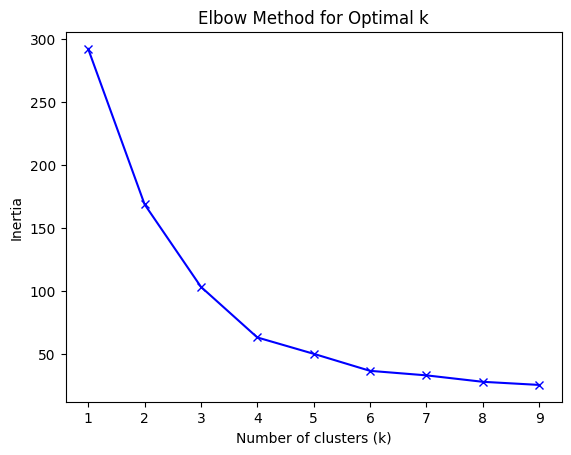

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()



2. Silhouette Score

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k={k}, silhouette score={score}")


k=2, silhouette score=0.4138703509112063
k=3, silhouette score=0.4276959809417726
k=4, silhouette score=0.46746104638602615
k=5, silhouette score=0.458742505418281


3. Visualize Clusters

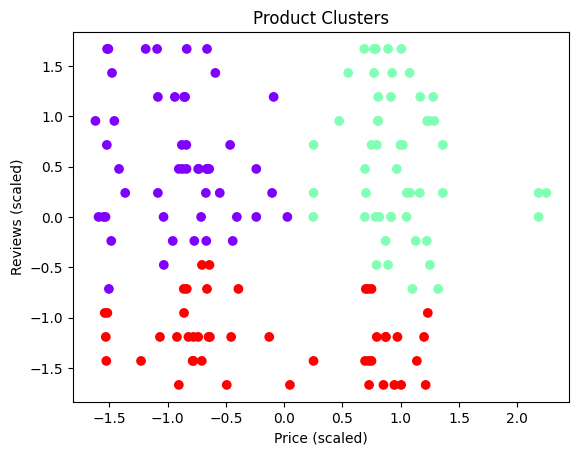

In [ ]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df["Cluster"], cmap='rainbow')
plt.xlabel("Price (scaled)")
plt.ylabel("Reviews (scaled)")
plt.title("Product Clusters")
plt.show()


In [ ]:
df.to_csv("products_clustered.csv", index=False)


##Supervised Learning
Supervised Learning is a machine learning technique where the model learns from labeled data to predict a specific outcome.

##1)Logistic Regression
Logistic Regression is a classification algorithm used to predict binary outcomes (Yes/No, 0/1).

Import Libraries

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score


Load Dataset

In [ ]:
import pandas as pd

# Load your cleaned dataset
df = pd.read_csv("final_products.csv")

# Target: is_expensive (Yes/No)
y = df["is_expensive"]

# Features: Price, Reviews, Category, Brand
X = df[["price", "reviews", "category", "brand"]]

Encode Categorical Variables

In [ ]:
# Encode category and brand
encoder = LabelEncoder()
X["category"] = encoder.fit_transform(X["category"])
X["brand"] = encoder.fit_transform(X["brand"])


/tmp/ipython-input-736/3474235063.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["category"] = encoder.fit_transform(X["category"])
/tmp/ipython-input-736/3474235063.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["brand"] = encoder.fit_transform(X["brand"])


Scale Numerical Features

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Split Train/Test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)


Train Models

In [ ]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))
print("Logistic Regression F1 Score:", f1_score(y_test, y_pred, pos_label="Yes"))


Logistic Regression Accuracy: 1.0
Logistic Regression F1 Score: 1.0


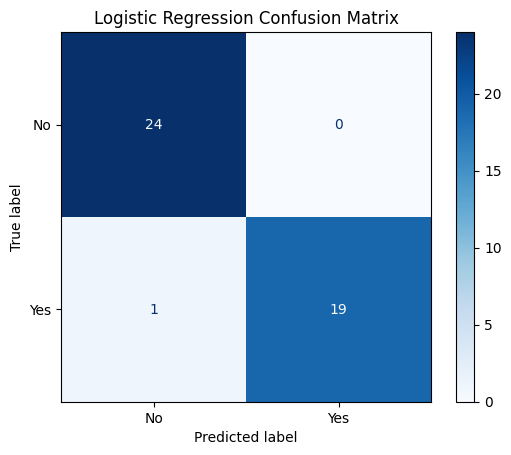

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=["No","Yes"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No","Yes"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Logistic Regression Confusion Matrix")
plt.show()


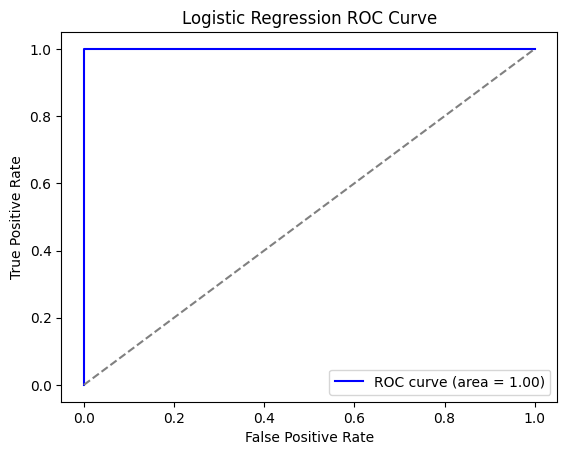

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = log_model.predict_proba(X_test)[:,1]  # probability for class "Yes"
fpr, tpr, thresholds = roc_curve(y_test, y_prob, pos_label="Yes")
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.legend()
plt.show()


##2)Support Vector Machine (SVM)
SVM is a classification algorithm that finds the best boundary (hyperplane) to separate different classes.

import libraries

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score


In [ ]:
# Load your cleaned dataset
df = pd.read_csv("final_products.csv")

# Target column
y = df["is_expensive"]

# Features
X = df[["price", "reviews", "category", "brand"]]

encoder = LabelEncoder()
X["category"] = encoder.fit_transform(X["category"])
X["brand"] = encoder.fit_transform(X["brand"])






/tmp/ipython-input-736/251496105.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["category"] = encoder.fit_transform(X["category"])
/tmp/ipython-input-736/251496105.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["brand"] = encoder.fit_transform(X["brand"])


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

svm_model = SVC(kernel="linear")   # kernel can be 'linear', 'rbf', 'poly'
svm_model.fit(X_train, y_train)






SVC(kernel='linear')

In [ ]:
y_pred = svm_model.predict(X_test)


In [ ]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print("SVM F1 Score:", f1_score(y_test, y_pred, pos_label="Yes"))


SVM Accuracy: 1.0
SVM F1 Score: 1.0


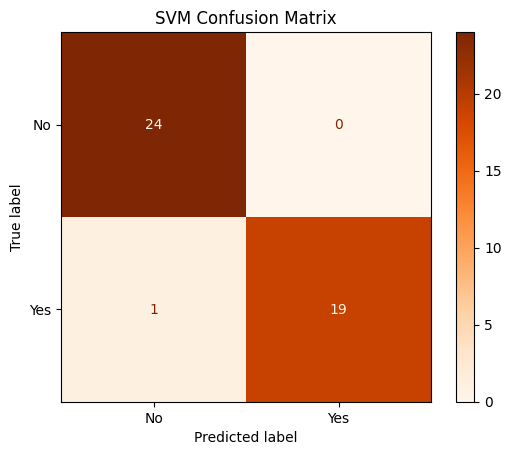

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=["No","Yes"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No","Yes"])
disp.plot(cmap=plt.cm.Oranges)
plt.title("SVM Confusion Matrix")
plt.show()


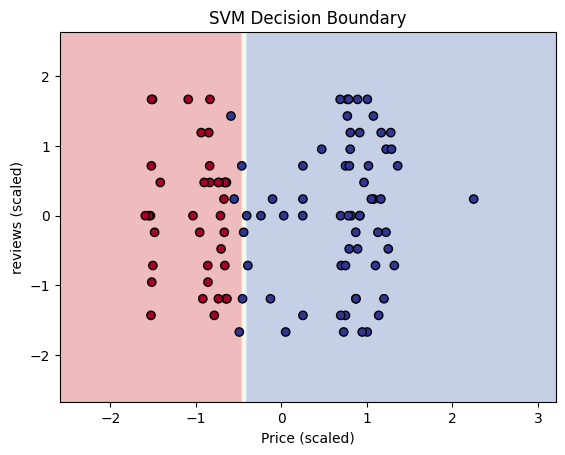

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Only 2 features for visualization
X_train_vis = X_train[:, :2] # Use training features for visualization
svm_model_vis = SVC(kernel="linear")

# Use y_train_numeric for fitting the model
# y_train_numeric was defined in cell 6zm40CAmRjHR.
svm_model_vis.fit(X_train_vis, y_train_numeric)

# Meshgrid for plotting
x_min, x_max = X_train_vis[:,0].min()-1, X_train_vis[:,0].max()+1
y_min, y_max = X_train_vis[:,1].min()-1, X_train_vis[:,1].max()+1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict over the meshgrid
# Z will now contain numerical values (0 or 1) because the model was trained with them.
Z = svm_model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
# Use y_train_numeric for coloring the scatter plot as well, for consistency with Z.
plt.scatter(X_train_vis[:,0], X_train_vis[:,1], c=y_train_numeric, edgecolor='k', cmap=plt.cm.RdYlBu)
plt.xlabel("Price (scaled)")
plt.ylabel("reviews (scaled)")
plt.title("SVM Decision Boundary")
plt.show()

##3)k-Nearest Neighbors (k-NN)
k-NN classifies a product based on the majority category of its nearest neighbors.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score


In [ ]:
# Load your cleaned dataset
df = pd.read_csv("final_products.csv")

# Target column
y = df["is_expensive"]

# Features
X = df[["price", "reviews", "category", "brand"]]


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# k=5 neighbors (you can tune this value)
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)

print("k-NN Accuracy:", accuracy_score(y_test, y_pred))
print("k-NN F1 Score:", f1_score(y_test, y_pred, pos_label="Yes"))





k-NN Accuracy: 0.9772727272727273
k-NN F1 Score: 0.9743589743589743


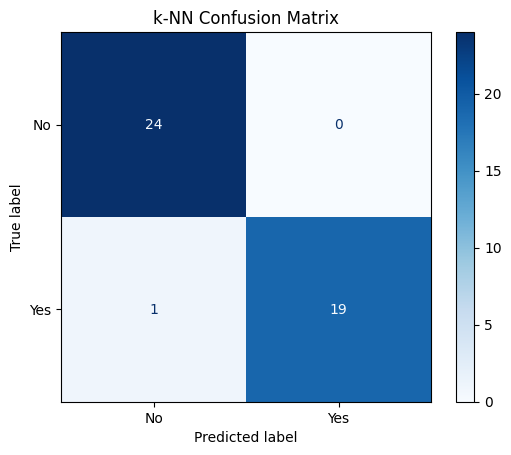

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["No","Yes"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No","Yes"])
disp.plot(cmap=plt.cm.Blues)
plt.title("k-NN Confusion Matrix")
plt.show()


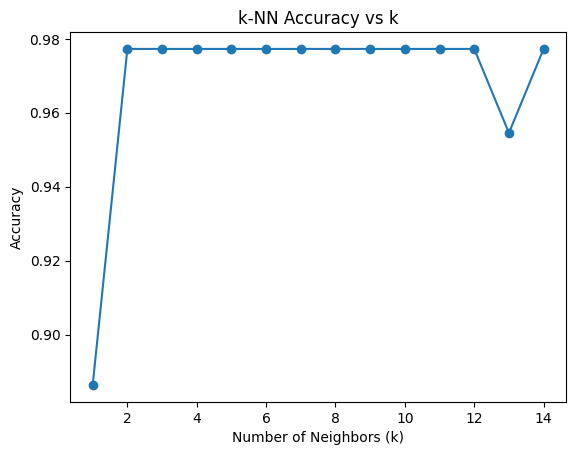

In [ ]:
import numpy as np

accuracy_scores = []
for k in range(1, 15):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracy_scores.append(accuracy_score(y_test, knn.predict(X_test)))

plt.plot(range(1, 15), accuracy_scores, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("k-NN Accuracy vs k")
plt.show()


##4)Random Forest
Random Forest is an ensemble algorithm that uses multiple decision trees and combines their results for better accuracy.


Random Forest Accuracy: 1.0
Random Forest F1 Score: 1.0


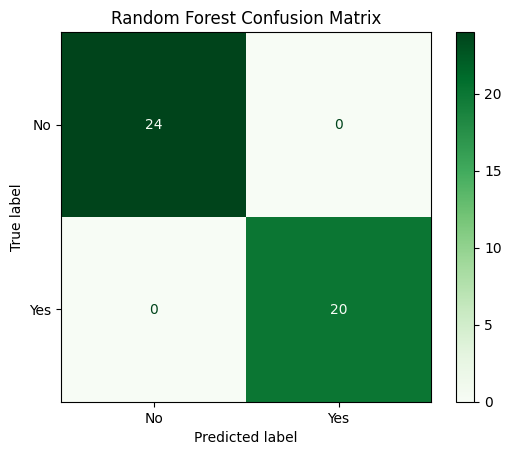

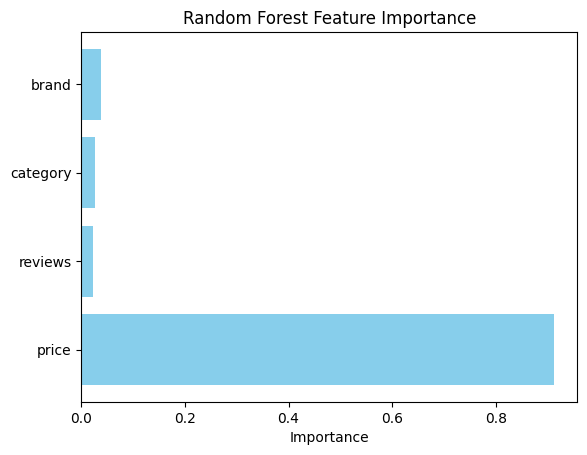

In [ ]:
# Step 1: Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Step 2: Load Dataset
df = pd.read_csv("final_products.csv")

# Target column
y = df["is_expensive"]

# Features
X = df[["price", "reviews", "category", "brand"]].copy()

# Step 3: Encode Categorical Variables
encoder = LabelEncoder()
X["category"] = encoder.fit_transform(X["category"])
X["brand"] = encoder.fit_transform(X["brand"])

# Step 4: Scale Numerical Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# Step 6: Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Step 7: Predictions
y_pred = rf_model.predict(X_test)

# Step 8: Evaluate Performance
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print("Random Forest F1 Score:", f1_score(y_test, y_pred, pos_label="Yes"))

# Step 9: Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["No","Yes"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No","Yes"])
disp.plot(cmap=plt.cm.Greens)
plt.title("Random Forest Confusion Matrix")
plt.show()

# Step 10: Feature Importance Graph
import numpy as np

importances = rf_model.feature_importances_
feature_names = ["price", "reviews", "category", "brand"]

plt.barh(feature_names, importances, color="skyblue")
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

##5)XGBoost
XGBoost (Extreme Gradient Boosting) is an advanced boosting algorithm that improves prediction performance by correcting errors step-by-step.

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:49:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 1.0
XGBoost F1 Score: 1.0


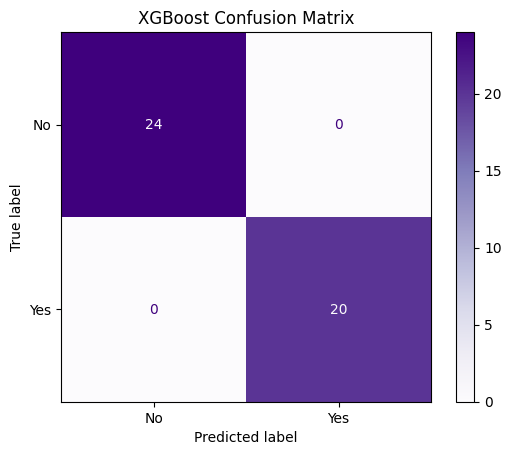

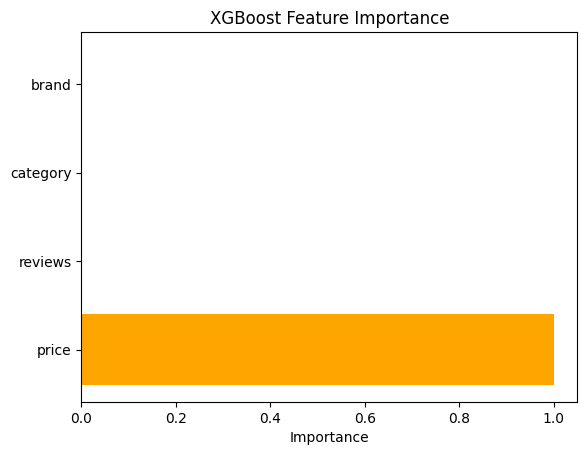

In [ ]:
# Step 1: Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import xgboost as xgb

# Step 2: Load Dataset
df = pd.read_csv("final_products.csv")

# Target column
y = df["is_expensive"]

# Features
X = df[["price", "reviews", "category", "brand"]].copy()

# Step 3: Encode Categorical Variables
encoder = LabelEncoder()
X["category"] = encoder.fit_transform(X["category"])
X["brand"] = encoder.fit_transform(X["brand"])

# Step 4: Scale Numerical Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert y to numerical labels for XGBoost
label_mapping = {'No': 0, 'Yes': 1}
y_numeric = y.map(label_mapping)

# Step 5: Split Train/Test
X_train, X_test, y_train_numeric, y_test_numeric = train_test_split(
    X_scaled, y_numeric, test_size=0.3, random_state=42
)

# Step 6: Train XGBoost Model
xgb_model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    n_estimators=100,
    random_state=42
)
xgb_model.fit(X_train, y_train_numeric)

# Step 7: Predictions
y_pred = xgb_model.predict(X_test)

# Step 8: Evaluate Performance
print("XGBoost Accuracy:", accuracy_score(y_test_numeric, y_pred))
print("XGBoost F1 Score:", f1_score(y_test_numeric, y_pred, pos_label=1))

# Step 9: Confusion Matrix
cm = confusion_matrix(y_test_numeric, y_pred, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No","Yes"])
disp.plot(cmap=plt.cm.Purples)
plt.title("XGBoost Confusion Matrix")
plt.show()

# Step 10: Feature Importance Graph
importances = xgb_model.feature_importances_
feature_names = ["price", "reviews", "category", "brand"]

plt.barh(feature_names, importances, color="orange")
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.show()

In [ ]:
encoder = LabelEncoder()
X["category"] = encoder.fit_transform(X["category"])
X["brand"] = encoder.fit_transform(X["brand"])


/tmp/ipython-input-736/2586512533.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["category"] = encoder.fit_transform(X["category"])
/tmp/ipython-input-736/2586512533.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["brand"] = encoder.fit_transform(X["brand"])


In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Define a mapping for the target variable 'is_expensive'
label_mapping = {'No': 0, 'Yes': 1}

# Convert y_train and y_test to numerical labels for models that require it (like XGBoost)
y_train_numeric = y_train.map(label_mapping)
y_test_numeric = y_test.map(label_mapping)

# SVM
svm_model = SVC()
svm_model.fit(X_train, y_train)
print("SVM Accuracy:", accuracy_score(y_test, svm_model.predict(X_test)))

# k-NN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
print("k-NN Accuracy:", accuracy_score(y_test, knn_model.predict(X_test)))

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_model.predict(X_test)))

# XGBoost
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss")
xgb_model.fit(X_train, y_train_numeric) # Use numerically encoded labels
print("XGBoost Accuracy:", accuracy_score(y_test_numeric, xgb_model.predict(X_test))) # Evaluate with numerically encoded labels

SVM Accuracy: 0.9772727272727273
k-NN Accuracy: 0.9772727272727273
Random Forest Accuracy: 1.0
XGBoost Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:29:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


##Hyperparameter Tuning

Hyperparameter Tuning is the process of optimizing a machine learning model by selecting the best combination of parameters to improve its performance.

It involves testing different parameter values (like depth, number of trees, learning rate, etc.) and choosing the configuration that gives the highest accuracy or best evaluation score.

In [ ]:
# Step 1: Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# Step 2: Load Dataset
df = pd.read_csv("final_products.csv")

# Target column
y = df["is_expensive"]

# Features
X = df[["price", "reviews", "category", "brand"]].copy()

# Step 3: Encode Categorical Variables
encoder = LabelEncoder()
X["category"] = encoder.fit_transform(X["category"])
X["brand"] = encoder.fit_transform(X["brand"])

# Step 4: Scale Numerical Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 5: Split Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# Step 6: Define Model
rf_model = RandomForestClassifier(random_state=42)

# Step 7: Define Hyperparameter Grid
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Step 8: Grid Search
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best Grid Search Parameters:", grid_search.best_params_)
print("Best Grid Search Accuracy:", grid_search.best_score_)

# Step 9: Random Search (alternative)
param_dist = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 6]
}

random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

print("Best Random Search Parameters:", random_search.best_params_)
print("Best Random Search Accuracy:", random_search.best_score_)

# Step 10: Evaluate Best Model on Test Data
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Final Test Accuracy:", accuracy_score(y_test, y_pred))
print("Final Test F1 Score:", f1_score(y_test, y_pred, pos_label="Yes"))

Best Grid Search Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Grid Search Accuracy: 1.0
Best Random Search Parameters: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': None}
Best Random Search Accuracy: 1.0
Final Test Accuracy: 1.0
Final Test F1 Score: 1.0


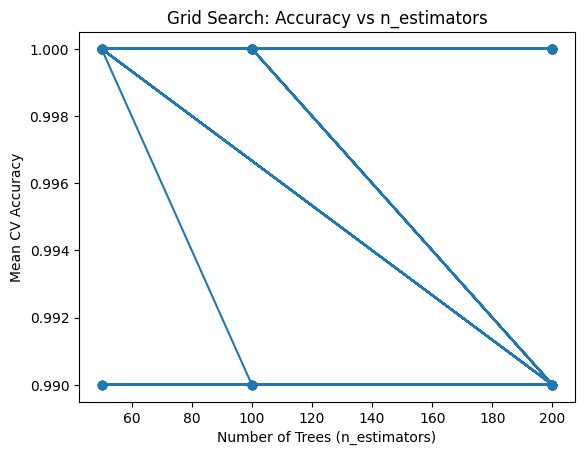

In [ ]:
import matplotlib.pyplot as plt

# Extract results from GridSearchCV
results = grid_search.cv_results_

# Plot mean accuracy for different n_estimators
plt.plot(results['param_n_estimators'], results['mean_test_score'], marker='o')
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Mean CV Accuracy")
plt.title("Grid Search: Accuracy vs n_estimators")
plt.show()


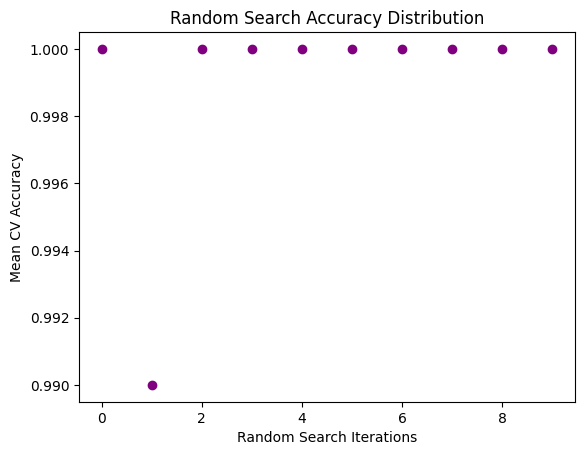

In [ ]:
results_random = random_search.cv_results_

plt.scatter(range(len(results_random['mean_test_score'])), results_random['mean_test_score'], color="purple")
plt.xlabel("Random Search Iterations")
plt.ylabel("Mean CV Accuracy")
plt.title("Random Search Accuracy Distribution")
plt.show()


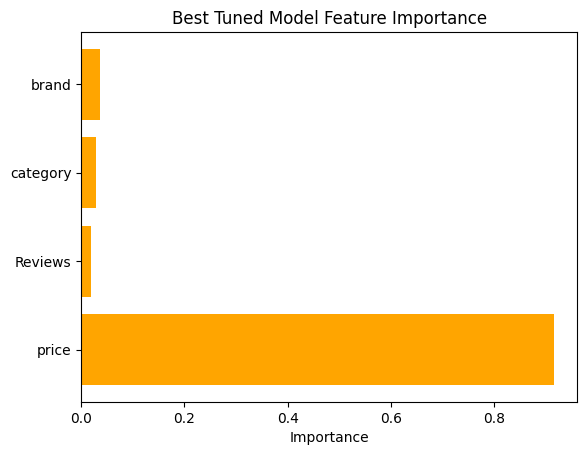

In [ ]:
best_model = random_search.best_estimator_
importances = best_model.feature_importances_
feature_names = ["price", "Reviews", "category", "brand"]

plt.barh(feature_names, importances, color="orange")
plt.xlabel("Importance")
plt.title("Best Tuned Model Feature Importance")
plt.show()
